In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

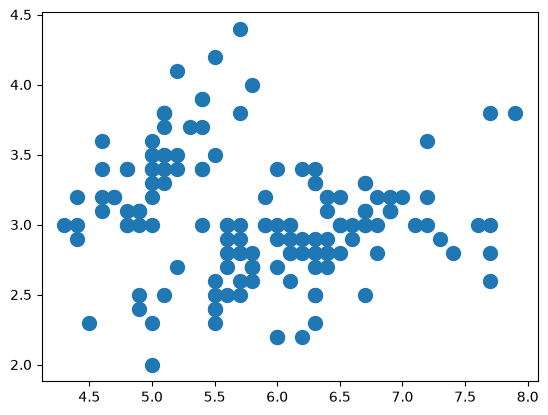

In [3]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [4]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2, n_init=10, random_state=0)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


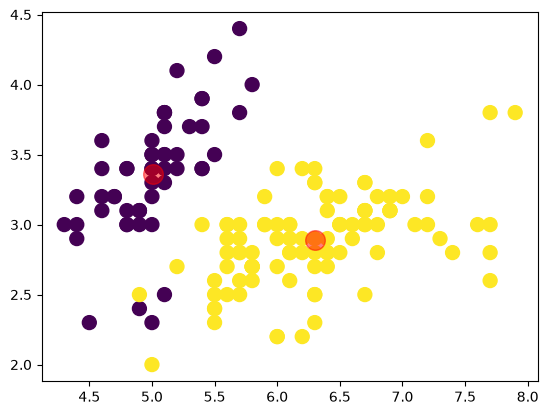

In [5]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [6]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733906


c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows wi

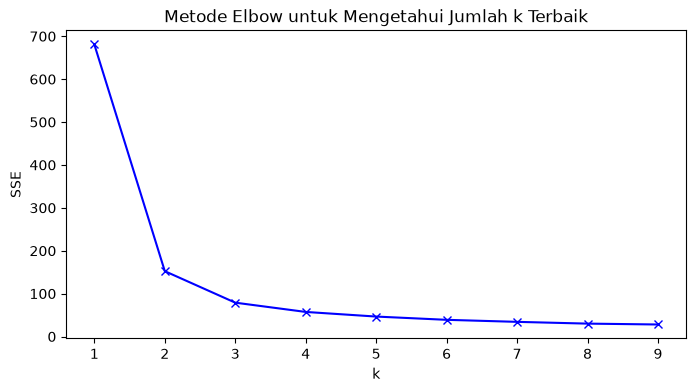

In [7]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k, n_init=10, random_state=0)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()


In [8]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8244
k=2; SSE=152.36870647733906
k=3; SSE=78.94084142614602
k=4; SSE=57.31787321428571
k=5; SSE=46.53558205128206
k=6; SSE=38.930963049671746
k=7; SSE=34.19698216257427
k=8; SSE=30.083825236167343
k=9; SSE=28.032802662999593


PRAKTIKUM 2

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import numpy as np

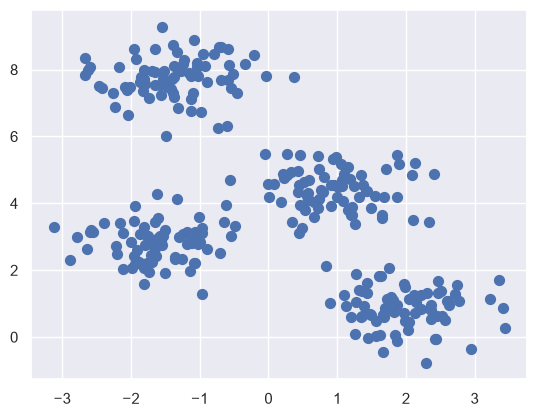

In [10]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [11]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, n_init=10, random_state=0)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


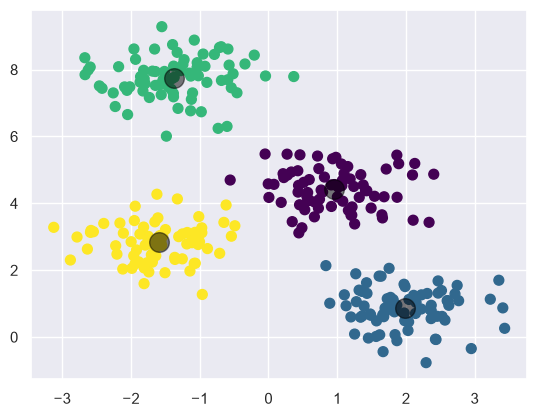

In [12]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

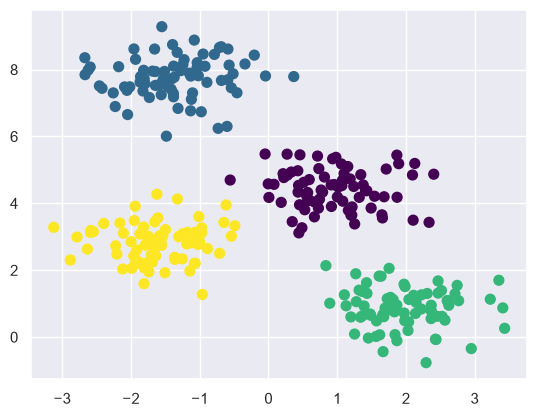

In [13]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]
    
    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)
        
        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])
        
        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers
    
    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

PERUBAHAN RANDOM

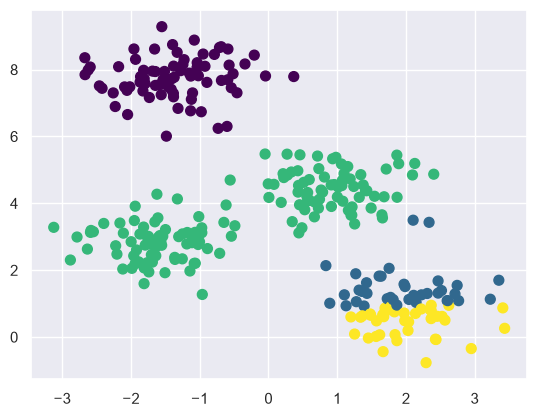

In [14]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

OPTIMASI JUMLAH KLUSTER

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


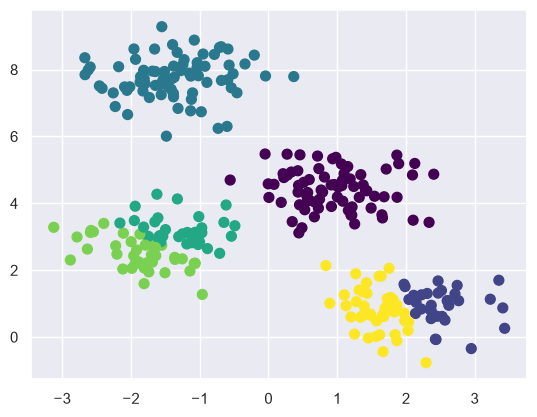

In [15]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

BATAS KLASTER YANG TIDAK SELALU LINIER

In [16]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


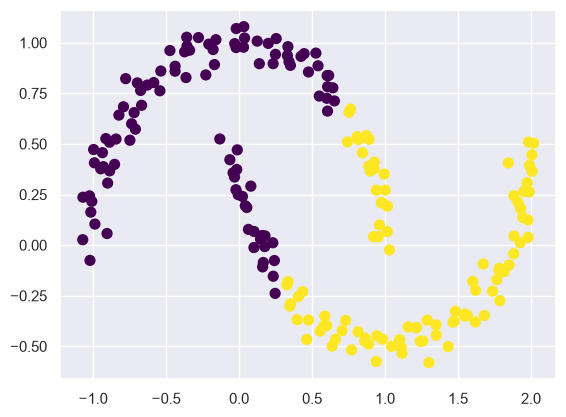

In [17]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

c:\Users\User\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


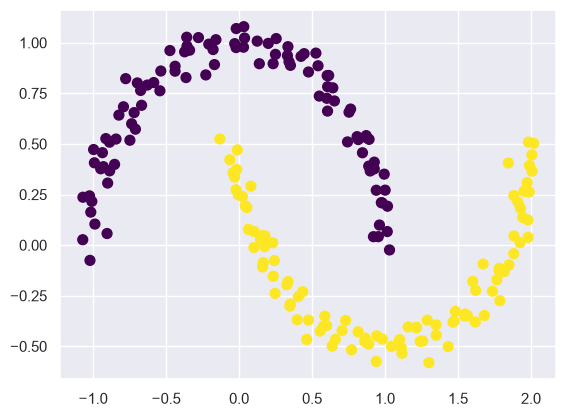

In [18]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

CONTOH KASUS 1: KARAKTER ANGKA

In [19]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [20]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, n_init=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


(10, 64)

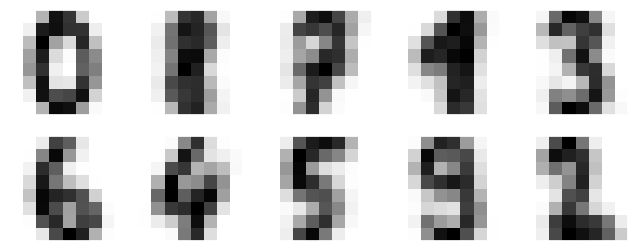

In [21]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [22]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7918753478018921

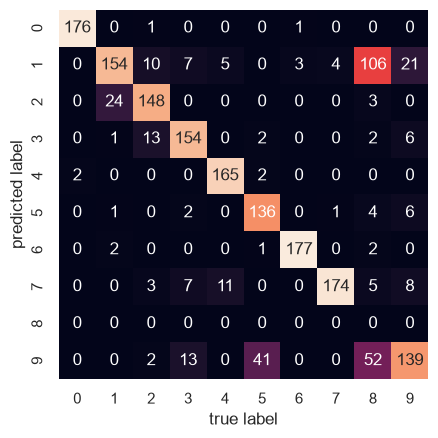

In [24]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [25]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, n_init=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


0.9410127991096272

STUDI KASUS 2: KOMPRESI CITRA

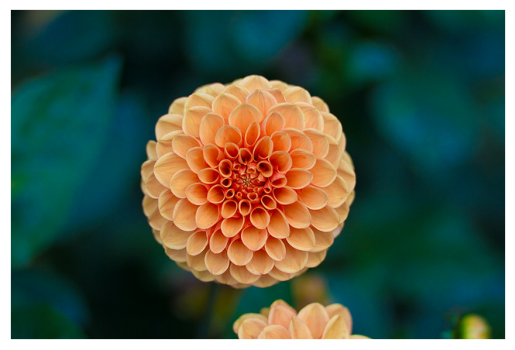

In [26]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [27]:
flower.shape

(427, 640, 3)

In [28]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [29]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    
    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

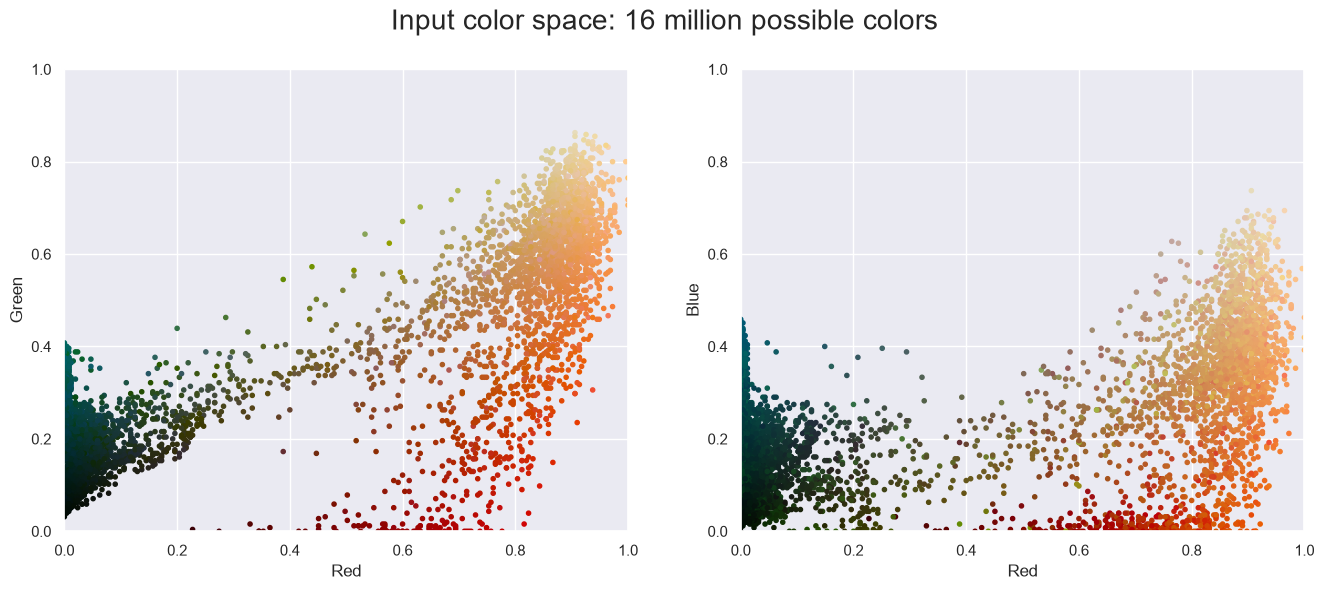

In [30]:
plot_pixels(data, title='Input color space: 16 million possible colors')

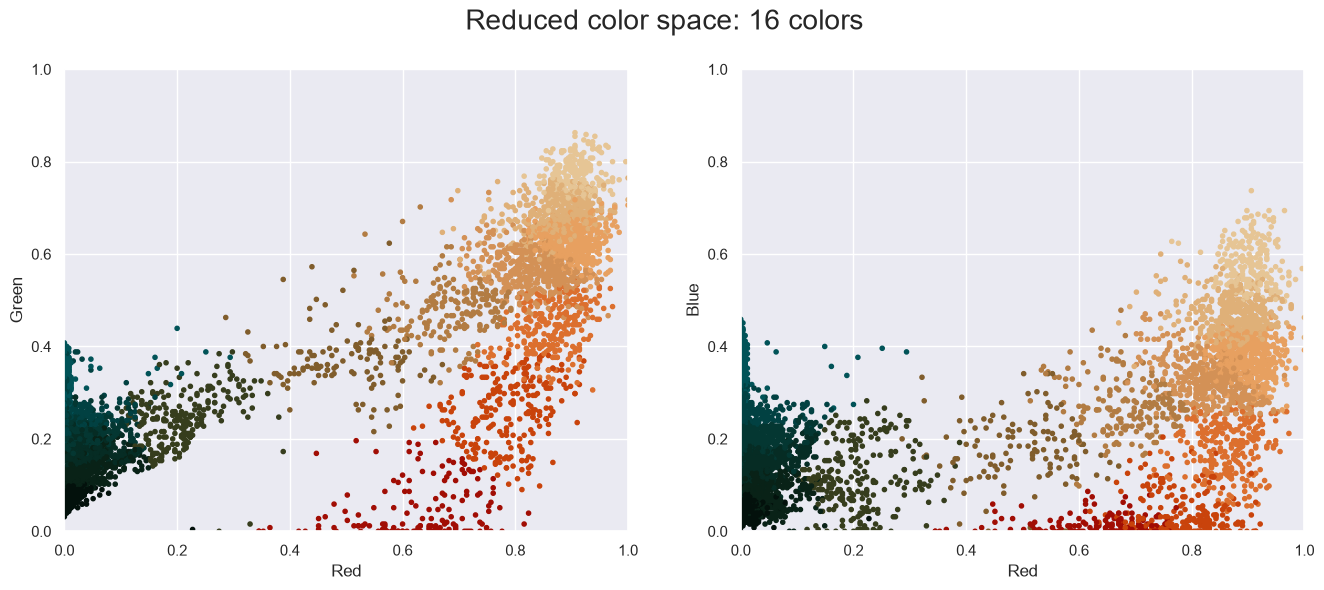

In [31]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

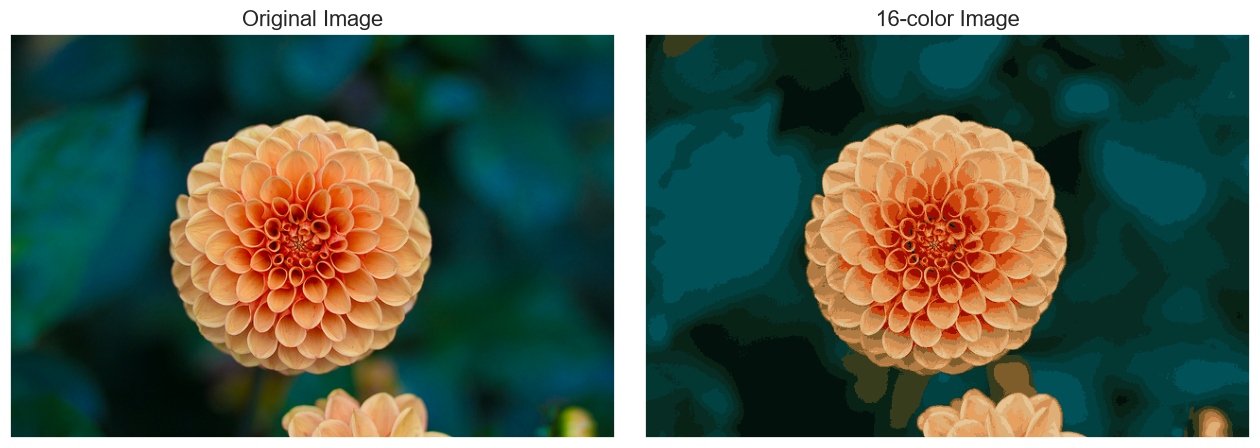

In [32]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

PRAKTIKUM 3

PEMBUATAN DATASET SINTETIS

In [33]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

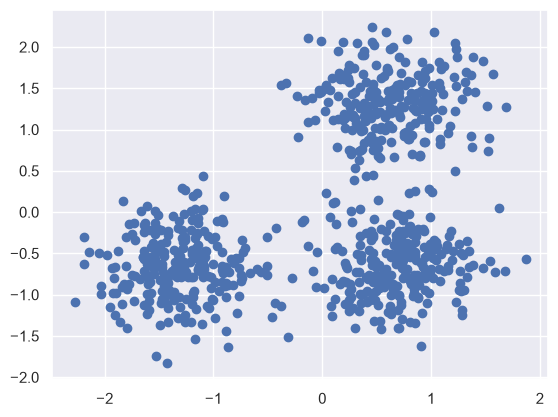

In [34]:
plt.scatter(X[:, 0], X[:, 1])
plt.show()

COMPUTE DBSCAN

In [35]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


EVALUASI KUALITAS KLASTERISASI

In [36]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


VISUALISASI HASIL KLASTERISASI

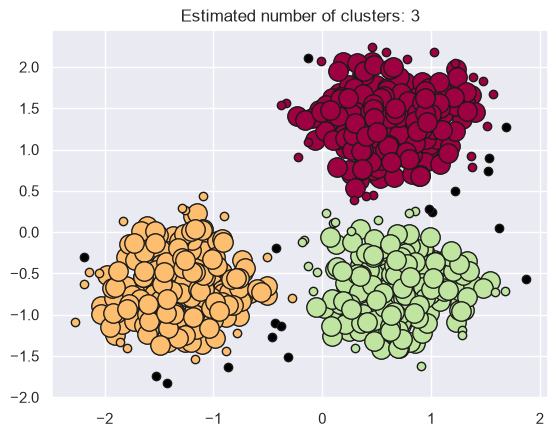

In [37]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

TUGAS PRAKTIKUM
1. Tugas K-Means
Buatlah sebuah model K-Means dengan ketentuan,

- Gunakan data 'Mall_Customers.csv'
- Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
- Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik.

1. Import & load data

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


2. Eksplorasi data

In [39]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Saya membuka file Mall_Customers.csv, berisi data 200 pelanggan mall. Tidak ada data kosong

3. Pemilihan fitur & normalisasi

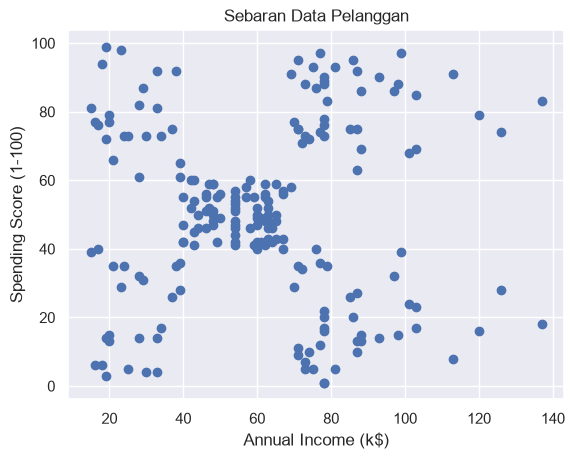

In [40]:
# Fitur yang digunakan untuk clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

# Normalisasi fitur agar skala seimbang
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Sebaran Data Pelanggan')
plt.show()

Saya memilih pendapatan tahunan dan skor belanja karena paling menggambarkan kebiasaan belanja. Data dinormalisasi supaya skala kedua kolom seimbang, sebab K-Means bekerja dengan jarak.

4. Cari k terbaik (Elbow dan Silhouette)

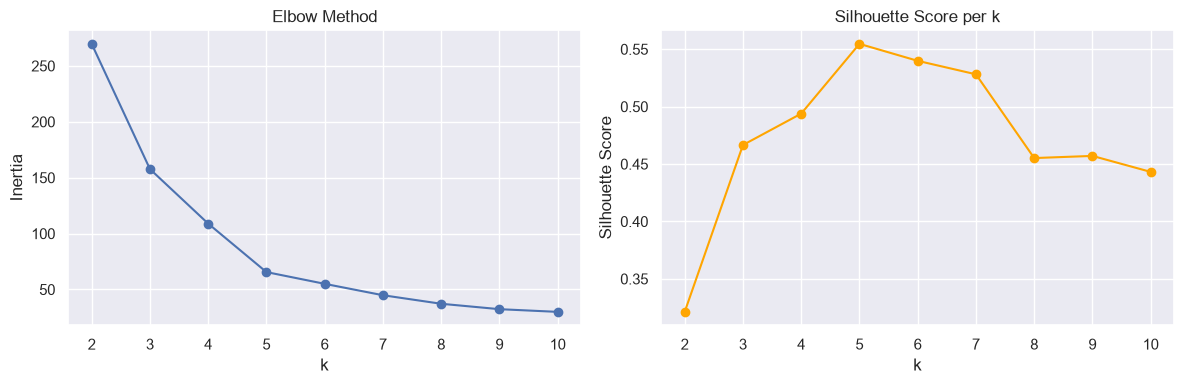

k terbaik: 5


In [41]:
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertia, marker='o')
ax[0].set(xlabel='k', ylabel='Inertia', title='Elbow Method')
ax[1].plot(K_range, silhouette, marker='o', color='orange')
ax[1].set(xlabel='k', ylabel='Silhouette Score', title='Silhouette Score per k')
plt.tight_layout()
plt.show()

best_k = K_range[int(np.argmax(silhouette))]
print('k terbaik:', best_k)

Saya mencoba k = 2 sampai 10. Grafik Elbow mulai melandai di k=5, dan skor Silhouette tertinggi juga di k=5 (0,555). Jadi k terbaik adalah 5.

5. Model final dan visualisasi

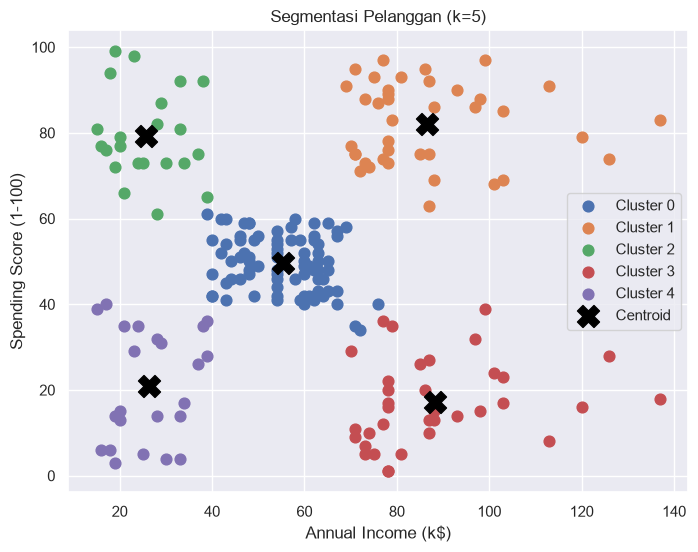

In [42]:
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
for c in range(best_k):
    pts = df[df['Cluster'] == c]
    plt.scatter(pts[features[0]], pts[features[1]], s=60, label=f'Cluster {c}')

centers = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=250, c='black', marker='X', label='Centroid')
plt.xlabel(features[0]); plt.ylabel(features[1])
plt.title(f'Segmentasi Pelanggan (k={best_k})')
plt.legend()
plt.show()

K-Means dijalankan dengan k=5. Grafik menampilkan 5 kelompok berwarna, dan tanda X hitam adalah pusat tiap kelompok (centroid).

Cek nomor cluster mana yang cocok dengan tiap segmen lewat:

In [43]:
df.groupby('Cluster')[features].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


Kesimpulan

- Cluster 0 (income ~55k$, spending ~50): pelanggan rata-rata
- Cluster 1 (income ~87k$, spending ~82): pelanggan premium, target utama
- Cluster 2 (income ~26k$, spending ~79): pelanggan impulsif
- Cluster 3 (income ~88k$, spending ~17): pelanggan hemat, cocok diberi promo khusus
- Cluster 4 (income ~26k$, spending ~21): pelanggan pasif

Pelanggan terbagi menjadi 5 kelompok, sehingga promo bisa dibuat berbeda untuk tiap kelompok.

2. TUGAS DBSCAN


1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.
2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.
3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.
4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).
5. Lakukan eksperimen:
- eps = 0.05, 0.1, 0.3, 0.5
- min_samples = 3, 10, 20
- Catat perubahan klaster, noise, dan kualitas evaluasi.

1. Buat dataset dan normalisasi

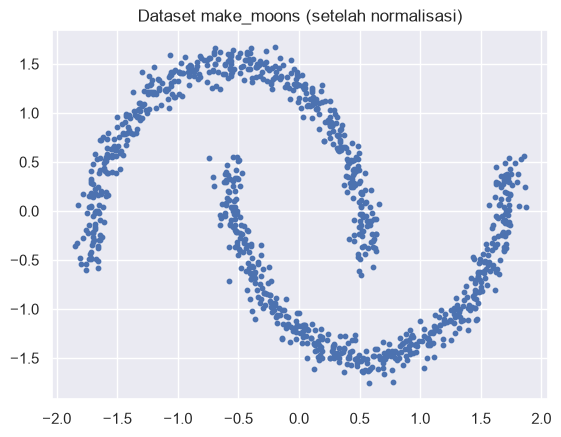

In [44]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

X_moons, y_moons_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

plt.scatter(X_moons[:, 0], X_moons[:, 1], s=10)
plt.title('Dataset make_moons (setelah normalisasi)')
plt.show()

Membuat 1000 titik berbentuk dua bulan sabit, lalu dinormalisasi agar skalanya seimbang.

2. Jalankan DBSCAN (eps=0.2, min_samples=5)

In [45]:
db = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')

Estimated number of clusters: 2
Estimated number of noise points: 0


Dengan eps=0.2 dan min_samples=5, ditemukan 2 klaster dan 0 noise.

3. Evaluasi metrik

In [46]:
print(f"Homogeneity: {metrics.homogeneity_score(y_moons_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_moons_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_moons_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(y_moons_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(y_moons_true, labels):.3f}")

if n_clusters_ > 1:
    print(f"Silhouette Coefficient: {metrics.silhouette_score(X_moons, labels):.3f}")
else:
    print('Silhouette Coefficient: tidak dapat dihitung (klaster < 2)')

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.391


Semua metrik berlabel asli bernilai 1.000, artinya hasilnya sama persis dengan label asli. Silhouette 0,391 rendah karena metrik ini kurang cocok untuk bentuk melengkung.

4. Visualisasi hasil

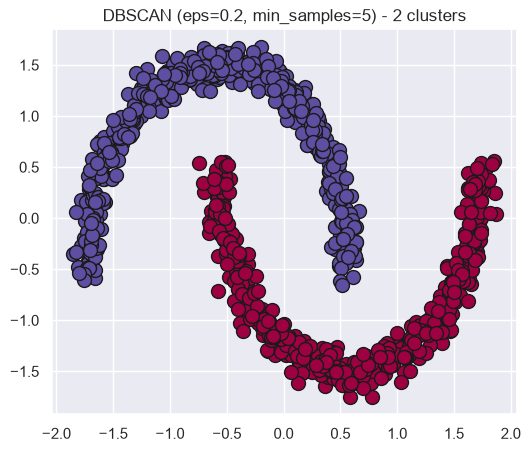

In [47]:
def plot_dbscan(X, db, title=''):
    labels = db.labels_
    unique_labels = set(labels)
    core_samples_mask = np.zeros_like(labels, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True

    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    plt.figure(figsize=(6, 5))
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # noise = hitam

        class_member_mask = labels == k

        # core sample = titik besar
        xy = X[class_member_mask & core_samples_mask]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=10)

        # non-core = titik kecil
        xy = X[class_member_mask & ~core_samples_mask]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=4)

    plt.title(title)
    plt.show()

plot_dbscan(X_moons, db, title=f'DBSCAN (eps=0.2, min_samples=5) - {n_clusters_} clusters')

Titik besar adalah core sample, titik kecil adalah non-core, dan titik hitam adalah noise. Di sini tidak ada noise, dan dua bulan sabit terpisah dengan warna berbeda.

5. Eksperimen eps dan min_samples

In [48]:
eps_values = [0.05, 0.1, 0.2, 0.3, 0.5]   # 0.2 ditambahkan sebagai pembanding
min_samples_values = [3, 10, 20]

results = []
for eps in eps_values:
    for ms in min_samples_values:
        lbl = DBSCAN(eps=eps, min_samples=ms).fit(X_moons).labels_

        n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = list(lbl).count(-1)
        non_noise = lbl != -1
        sil = metrics.silhouette_score(X_moons[non_noise], lbl[non_noise]) if n_clust > 1 else np.nan

        results.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clust,
            'n_noise': n_noise,
            'homogeneity': metrics.homogeneity_score(y_moons_true, lbl),
            'completeness': metrics.completeness_score(y_moons_true, lbl),
            'v_measure': metrics.v_measure_score(y_moons_true, lbl),
            'ari': metrics.adjusted_rand_score(y_moons_true, lbl),
            'ami': metrics.adjusted_mutual_info_score(y_moons_true, lbl),
            'silhouette': sil,
        })

results_df = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
results_df

,eps,min_samples,n_clusters,n_noise,homogeneity,completeness,v_measure,ari,ami,silhouette
0,0.050,3,69,186,0.816,0.153,0.257,0.030,0.244,0.349
1,0.050,10,3,970,0.031,0.127,0.049,0.002,0.046,0.881
2,0.050,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
3,0.100,3,2,14,0.986,0.903,0.943,0.972,0.943,0.394
4,0.100,10,7,57,0.943,0.410,0.571,0.523,0.570,0.210
5,0.100,20,6,850,0.154,0.155,0.155,0.017,0.151,0.787
6,0.200,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391
7,0.200,10,2,0,1.000,1.000,1.000,1.000,1.000,0.391
8,0.200,20,2,3,1.000,0.974,0.987,0.994,0.987,0.395
9,0.300,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391


ANALISIS EKSPERIMEN DBSCAN

*Pengaruh eps*
- eps = 0.05 (terlalu kecil): klaster pecah atau hampir semua titik jadi noise.
  Contoh: min_samples=3 menghasilkan 69 klaster dan 186 noise; min_samples=20
  menghasilkan 0 klaster dan 1000 noise.
- eps = 0.1: hasil bergantung min_samples. Dengan min_samples=3 didapat 2 klaster
  dan 14 noise (V-measure 0.943), tetapi min_samples=10 menjadi 7 klaster dan
  min_samples=20 menjadi 6 klaster dengan 850 noise.
- eps = 0.2: stabil untuk min_samples 3 dan 10 (2 klaster, 0 noise), tetapi pada
  min_samples=20 muncul 3 noise (completeness turun jadi 0.974).
- eps = 0.3 dan 0.5: stabil, selalu 2 klaster, 0 noise, semua metrik = 1.000.

*Pengaruh min_samples*
Semakin besar min_samples, semakin ketat syarat sebuah titik menjadi core point,
sehingga noise bertambah, terutama jika eps kecil.

*Kualitas evaluasi*
Homogeneity, Completeness, V-measure, ARI, dan AMI turun tajam saat klaster
pecah atau banyak noise. Silhouette tetap 0.391 pada hasil yang sempurna karena
bentuk moons tidak konveks, sehingga silhouette kurang cocok untuk dataset ini.
Catatan: setelah noise dikeluarkan, silhouette bisa tinggi (mis. 0.881 pada
eps=0.05, min_samples=10) padahal 970 dari 1000 titik adalah noise dan V-measure
hanya 0.049. Jadi silhouette harus dibaca bersama jumlah noise dan metrik
berlabel, tidak boleh dipakai sendirian.

*Kesimpulan:* parameter terbaik ada pada eps 0.2-0.5 dengan min_samples kecil
sampai sedang; eps terlalu kecil menyebabkan over-segmentation atau noise berlebih.

6. Visualisasi beberapa kombinasi

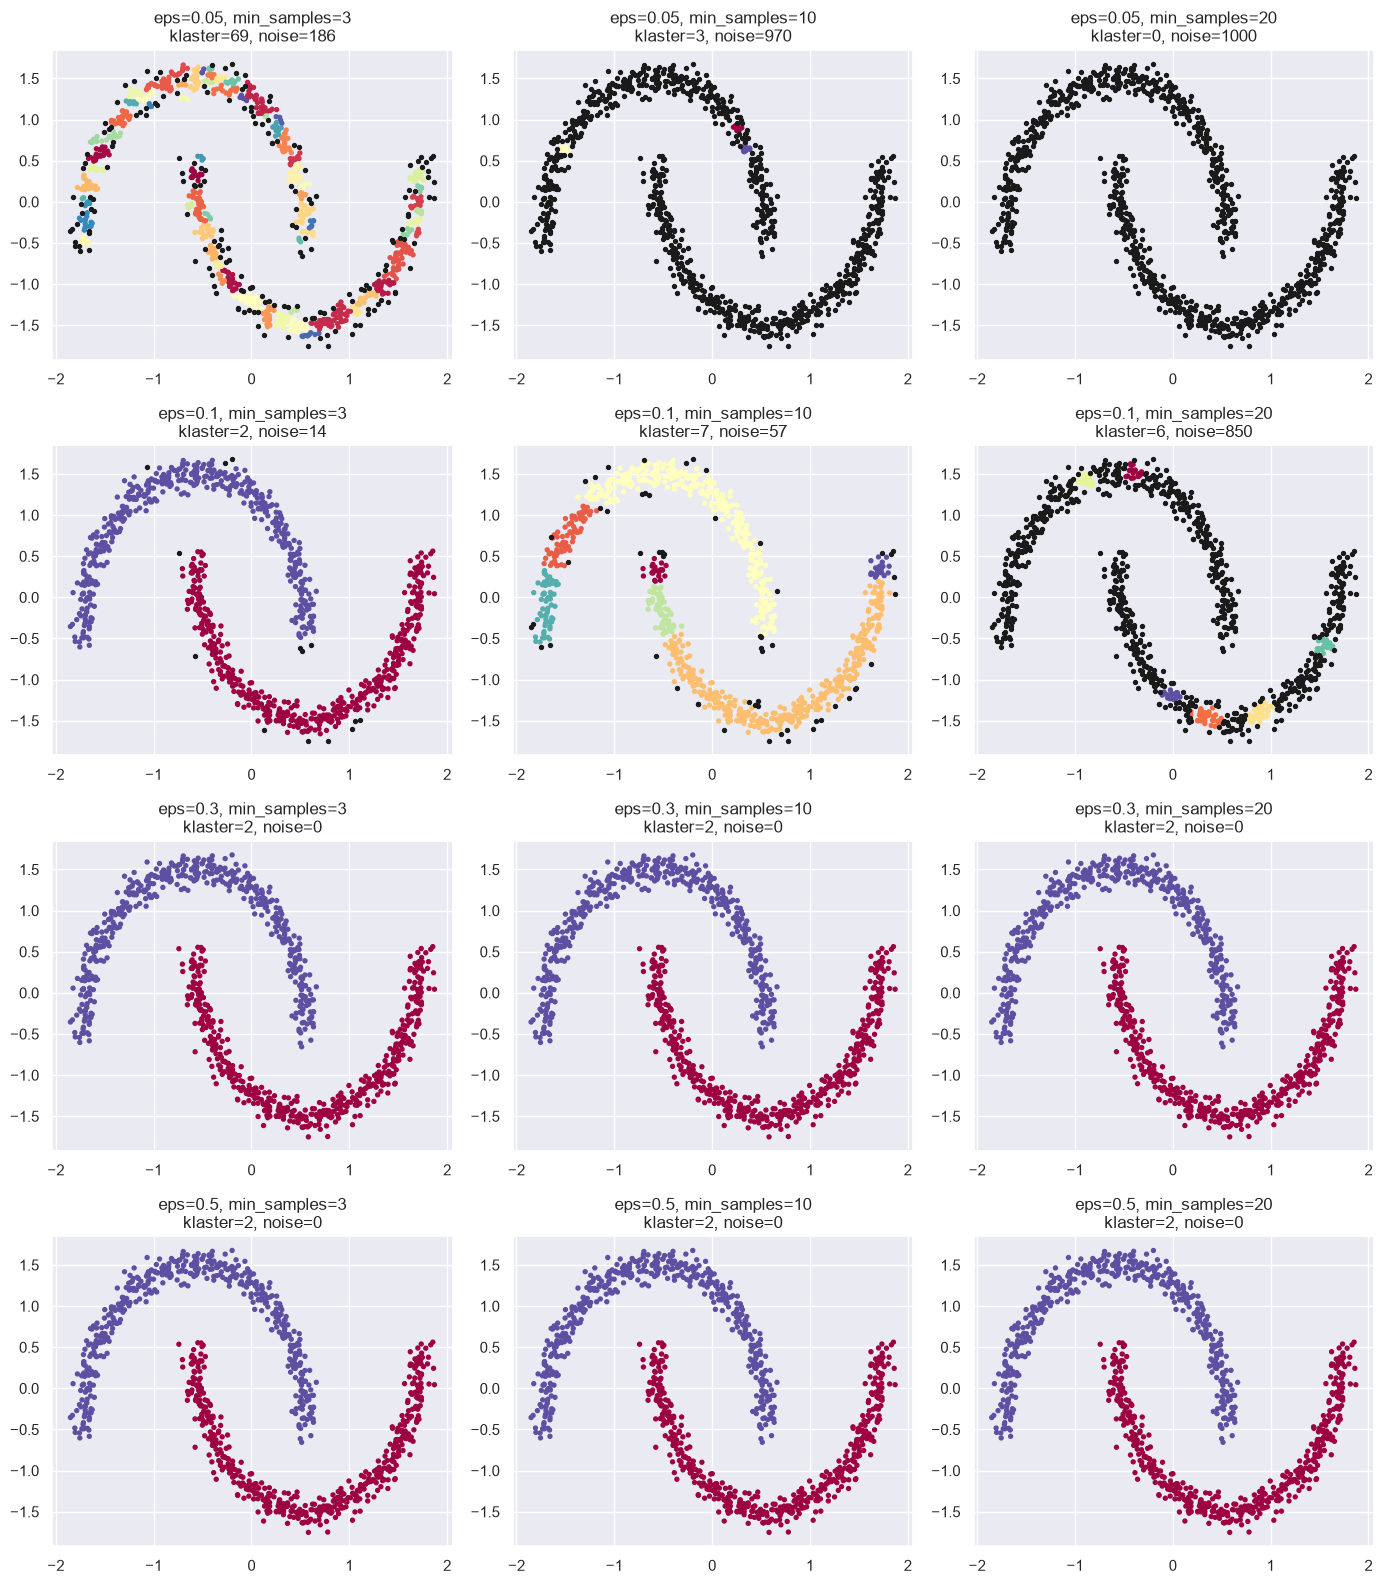

In [49]:
eps_list = [0.05, 0.1, 0.3, 0.5]
ms_list = [3, 10, 20]

fig, axes = plt.subplots(len(eps_list), len(ms_list), figsize=(14, 16))

for i, eps in enumerate(eps_list):
    for j, ms in enumerate(ms_list):
        ax = axes[i, j]
        lbl = DBSCAN(eps=eps, min_samples=ms).fit(X_moons).labels_
        n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = list(lbl).count(-1)
        noise = lbl == -1

        ax.scatter(X_moons[~noise, 0], X_moons[~noise, 1],
                   c=lbl[~noise], cmap='Spectral', s=8)
        ax.scatter(X_moons[noise, 0], X_moons[noise, 1], c='k', s=8)
        ax.set_title(f'eps={eps}, min_samples={ms}\nklaster={n_clust}, noise={n_noise}')

plt.tight_layout()
plt.show()

Menampilkan hasil tiap eps berdampingan, sehingga terlihat perubahan dari klaster pecah menjadi dua bulan sabit yang benar.

Kesimpulan
DBSCAN memisahkan dua bulan sabit dengan sempurna tanpa perlu menentukan jumlah klaster. Hasilnya sangat dipengaruhi eps, dan rentang 0.2 sampai 0.5 paling baik.